## 1. Импорты

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from wordcloud import WordCloud
from sklearn.datasets import fetch_20newsgroups
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

## 2. Загрузка данных

In [41]:
categories = [
    'comp.graphics',
    'rec.sport.baseball',
    'sci.space',
    'talk.politics.mideast',
    'soc.religion.christian'
]

newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print(f"Загружено документов: {len(newsgroups.data)}")
print(f"Классы: {newsgroups.target_names}")

df = pd.DataFrame({
    'text': newsgroups.data,
    'target': newsgroups.target,
    'class_name': [newsgroups.target_names[i] for i in newsgroups.target]
})

df['text_length'] = df['text'].apply(len)

print(f"Размер таблицы: {df.shape}")
print("\nПервые 3 строки:")
for i in range(3):
    print(f"\n--- Документ {i} (класс: {df.iloc[i]['class_name']}) ---")
    print(df.iloc[i]['text'][:200] + "..." if len(df.iloc[i]['text']) > 200 else df.iloc[i]['text'])

Загружено документов: 4891
Классы: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'soc.religion.christian', 'talk.politics.mideast']
Размер таблицы: (4891, 4)

Первые 3 строки:

--- Документ 0 (класс: comp.graphics) ---

(1) No explicit (c) is necessary.  If it the image is attributed to the
Geosphere Company, then there is a likelihood permission is has been
given to reprint.

(2) Unlikely that the owner can or will...

--- Документ 1 (класс: comp.graphics) ---
Does anyone have a radon transform in C that they could 
send me?

				Any help accepted,

--- Документ 2 (класс: talk.politics.mideast) ---
The comparison of the Palestinian situation with the Holocaust
is insulting and completely false.  Any person making such a rude
and false comparison is either ignorant of the Holocaust, or also
ignor...


## 3. EDA - количество документов по классам

Количество документов по классам:
class_name
soc.religion.christian    997
rec.sport.baseball        994
sci.space                 987
comp.graphics             973
talk.politics.mideast     940


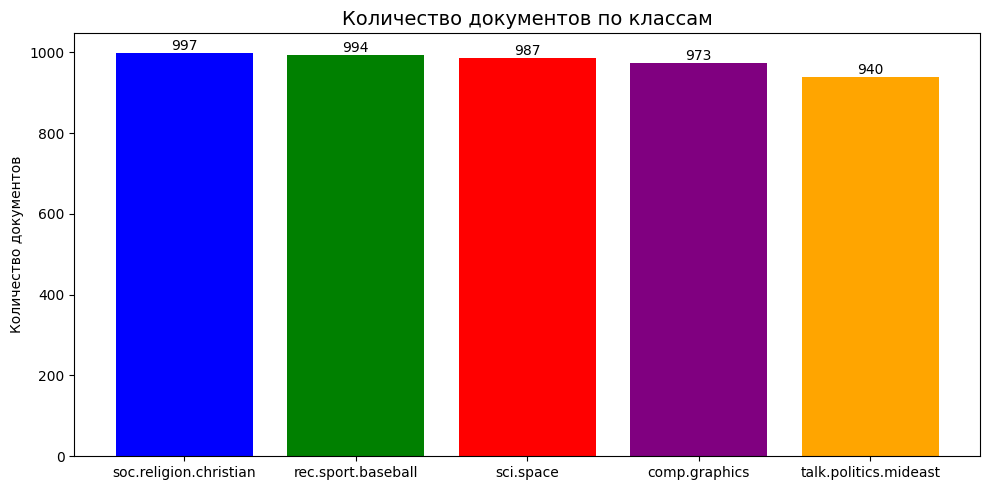


Минимум документов: 940
Максимум документов: 997
Разница между макс и мин: 57


In [42]:
class_counts = df['class_name'].value_counts()
print("Количество документов по классам:")
print(class_counts.to_string())

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.index, class_counts.values, color=['blue', 'green', 'red', 'purple', 'orange'])
plt.title('Количество документов по классам', fontsize=14)
plt.ylabel('Количество документов')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(f"\nМинимум документов: {class_counts.min()}")
print(f"Максимум документов: {class_counts.max()}")
print(f"Разница между макс и мин: {class_counts.max() - class_counts.min()}")

## 4. Средняя длина текста

Средняя длина текста по классам (в символах):
class_name
rec.sport.baseball         724
sci.space                 1213
comp.graphics             1294
soc.religion.christian    1628
talk.politics.mideast     2146
Name: text_length, dtype: int64


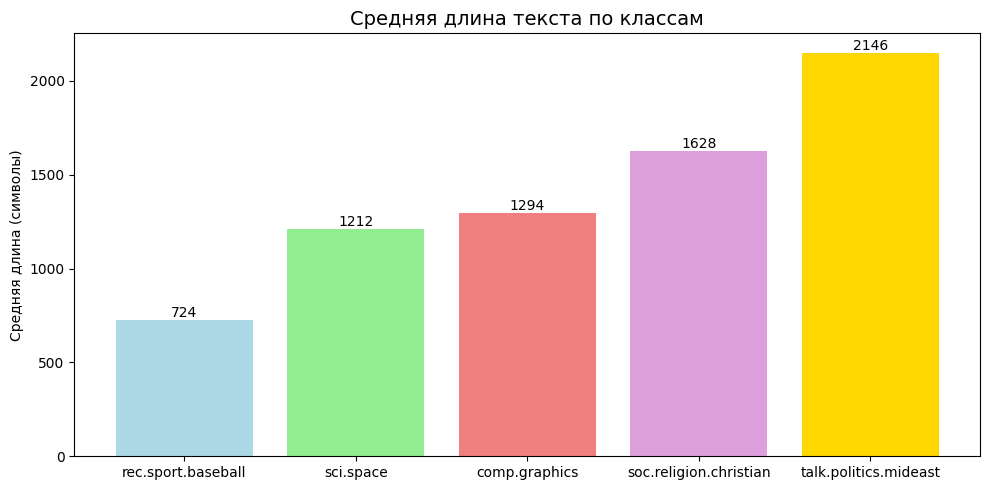


Общая статистика по длине текстов:
Минимальная длина: 0 символов
Максимальная длина: 61686 символов
Средняя длина: 1394 символов
Медианная длина: 549 символов


In [43]:
class_length = df.groupby('class_name')['text_length'].mean().sort_values()
print("Средняя длина текста по классам (в символах):")
print(class_length.round().astype(int))

plt.figure(figsize=(10, 5))
bars = plt.bar(class_length.index, class_length.values, 
               color=['lightblue', 'lightgreen', 'lightcoral', 'plum', 'gold'])
plt.title('Средняя длина текста по классам', fontsize=14)
plt.ylabel('Средняя длина (символы)')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(f"\nОбщая статистика по длине текстов:")
print(f"Минимальная длина: {df['text_length'].min()} символов")
print(f"Максимальная длина: {df['text_length'].max()} символов")
print(f"Средняя длина: {df['text_length'].mean():.0f} символов")
print(f"Медианная длина: {df['text_length'].median():.0f} символов")

## 5. Удаление пустых документов

In [44]:
initial_count = len(df)
df = df[df['text'].str.strip().astype(bool)].reset_index(drop=True)
df['clean_text'] = df['text'].str.strip()

df['text_length'] = df['clean_text'].str.len()

print(f"Удалено пустых документов: {initial_count - len(df)}")
print(f"Осталось документов: {len(df)}")

class_counts_after = df['class_name'].value_counts()
print("\nКоличество документов по классам:")
print(class_counts_after.to_string())

print("\nСтатистика длины текстов (общая):")
print(f"Минимум: {df['text_length'].min()}")
print(f"Максимум: {df['text_length'].max()}")
print(f"Среднее: {df['text_length'].mean():.2f}")
print(f"Медиана: {df['text_length'].median()}")

Удалено пустых документов: 129
Осталось документов: 4762

Количество документов по классам:
class_name
soc.religion.christian    975
rec.sport.baseball        958
comp.graphics             955
sci.space                 955
talk.politics.mideast     919

Статистика длины текстов (общая):
Минимум: 3
Максимум: 61684
Среднее: 1429.70
Медиана: 568.5


## 6. Boxplot 

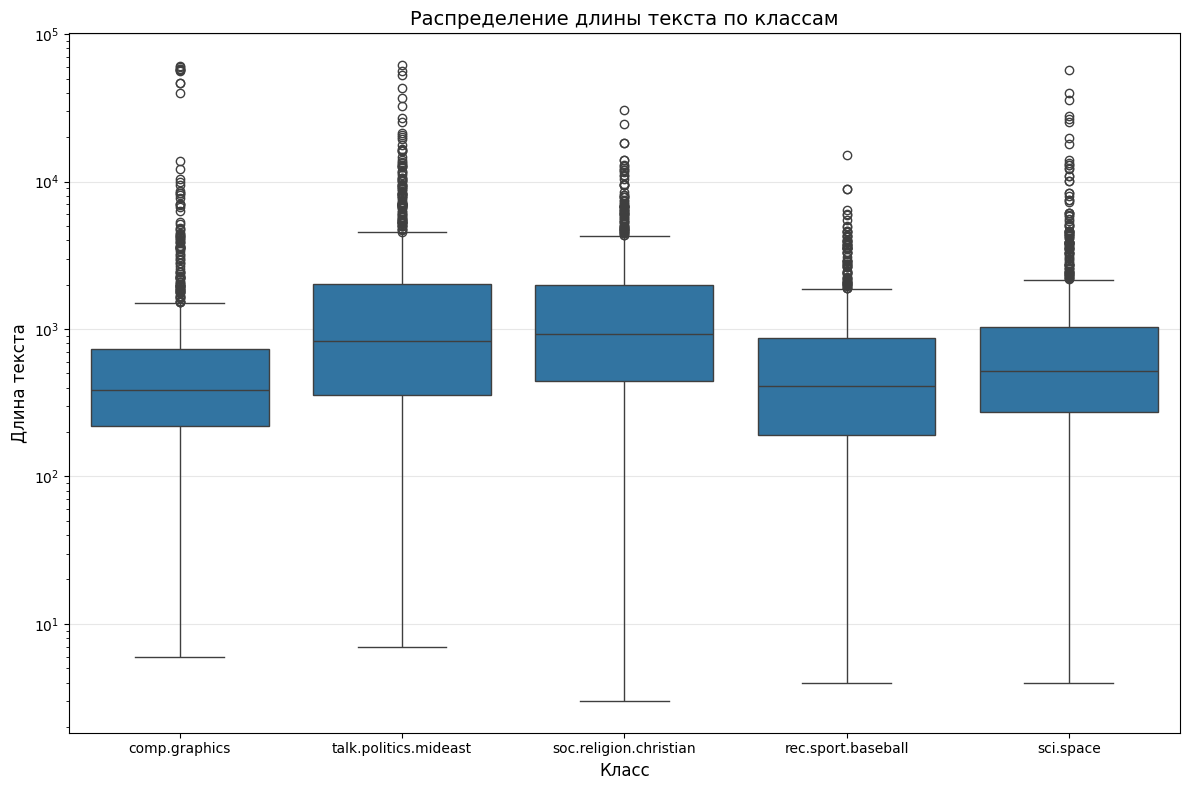

Медианная длина текста по классам:
class_name
comp.graphics             386.0
rec.sport.baseball        413.0
sci.space                 521.0
soc.religion.christian    921.0
talk.politics.mideast     829.0


In [45]:
plt.figure(figsize=(12,8))
ax=sns.boxplot(data=df, x='class_name', y='text_length')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')
plt.title('Распределение длины текста по классам', fontsize=14)
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Длина текста', fontsize=12)

plt.tight_layout()
plt.show()

print('Медианная длина текста по классам:')
medians=df.groupby('class_name')['text_length'].median()
print(medians.to_string())

## 7. Анализ выбросов по IQR

In [46]:
for class_name in df['class_name'].unique():
    data = df[df['class_name'] == class_name]['text_length']
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    
    outliers_upper = data[data > upper_whisker]
    outliers_lower = data[data < lower_whisker]
    
    print(f"\n{class_name}:")
    print(f"Q1 (25%): {Q1:.0f} символов")
    print(f"Q3 (75%): {Q3:.0f} символов")
    print(f"IQR: {IQR:.0f}")
    print(f"Верхний ус: {upper_whisker:.0f}")
    print(f"Минимум в данных: {data.min():.0f}")
    print(f"Максимум в данных: {data.max():.0f}")
    print(f"Выбросы сверху: {len(outliers_upper)} ({len(outliers_upper)/len(data)*100:.1f}%)")
    print(f"Выбросы снизу: {len(outliers_lower)} ({len(outliers_lower)/len(data)*100:.1f}%)")


comp.graphics:
Q1 (25%): 220 символов
Q3 (75%): 737 символов
IQR: 517
Верхний ус: 1512
Минимум в данных: 6
Максимум в данных: 61278
Выбросы сверху: 100 (10.5%)
Выбросы снизу: 0 (0.0%)

talk.politics.mideast:
Q1 (25%): 356 символов
Q3 (75%): 2036 символов
IQR: 1680
Верхний ус: 4555
Минимум в данных: 7
Максимум в данных: 61684
Выбросы сверху: 97 (10.6%)
Выбросы снизу: 0 (0.0%)

soc.religion.christian:
Q1 (25%): 444 символов
Q3 (75%): 1988 символов
IQR: 1544
Верхний ус: 4304
Минимум в данных: 3
Максимум в данных: 30738
Выбросы сверху: 71 (7.3%)
Выбросы снизу: 0 (0.0%)

rec.sport.baseball:
Q1 (25%): 192 символов
Q3 (75%): 873 символов
IQR: 681
Верхний ус: 1894
Минимум в данных: 4
Максимум в данных: 15161
Выбросы сверху: 76 (7.9%)
Выбросы снизу: 0 (0.0%)

sci.space:
Q1 (25%): 274 символов
Q3 (75%): 1027 символов
IQR: 753
Верхний ус: 2156
Минимум в данных: 4
Максимум в данных: 56793
Выбросы сверху: 96 (10.1%)
Выбросы снизу: 0 (0.0%)


## 8. Токенизация и топ-20 слов ДО предобработки

In [47]:
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

def top_words_class(df, n=20):
    top_words={}
    
    for class_name in df['class_name'].unique():
        texts=df[df['class_name'] == class_name]['text'].tolist()
        all_words=[]
        for text in texts:
            words=word_tokenize(text.lower())
            all_words.extend(words)
        counter=Counter(all_words)
        top_words[class_name]=counter.most_common(n)
        print(f"\n{class_name}:")
        for word, count in top_words[class_name][:n]:
            print(f"  {word}: {count}")
    
    return top_words

top_words_before = top_words_class(df, n=20)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\filip\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



comp.graphics:
  ,: 10985
  .: 9335
  the: 7326
  --: 7090
  to: 4476
  a: 4271
  and: 4129
  ): 3714
  of: 3680
  (: 3491
  is: 2939
  :: 2787
  i: 2613
  for: 2603
  in: 2386
  *: 2242
  it: 2147
  you: 1909
  that: 1540
  on: 1429

talk.politics.mideast:
  the: 20881
  ,: 20821
  .: 16888
  of: 10330
  and: 8716
  to: 8531
  in: 6765
  a: 5151
  that: 4577
  i: 4372
  '': 3439
  is: 3308
  it: 2950
  ``: 2938
  was: 2840
  they: 2790
  --: 2727
  you: 2628
  for: 2277
  on: 2234

soc.religion.christian:
  the: 15552
  ,: 13605
  .: 13158
  of: 8689
  to: 8208
  and: 6043
  that: 5627
  is: 5380
  in: 5081
  a: 4920
  i: 4863
  it: 3388
  not: 3003
  '': 2674
  you: 2482
  ): 2377
  this: 2332
  --: 2320
  for: 2312
  be: 2298

rec.sport.baseball:
  ,: 6294
  .: 6129
  the: 6010
  --: 4048
  to: 2766
  a: 2715
  i: 2241
  and: 2153
  of: 2044
  in: 1945
  that: 1626
  is: 1565
  ): 1498
  he: 1237
  (: 1183
  's: 1162
  it: 1091
  for: 997
  *: 959
  ?: 954

sci.space:
  the: 10442


## 9. Облака слов ДО предобработки

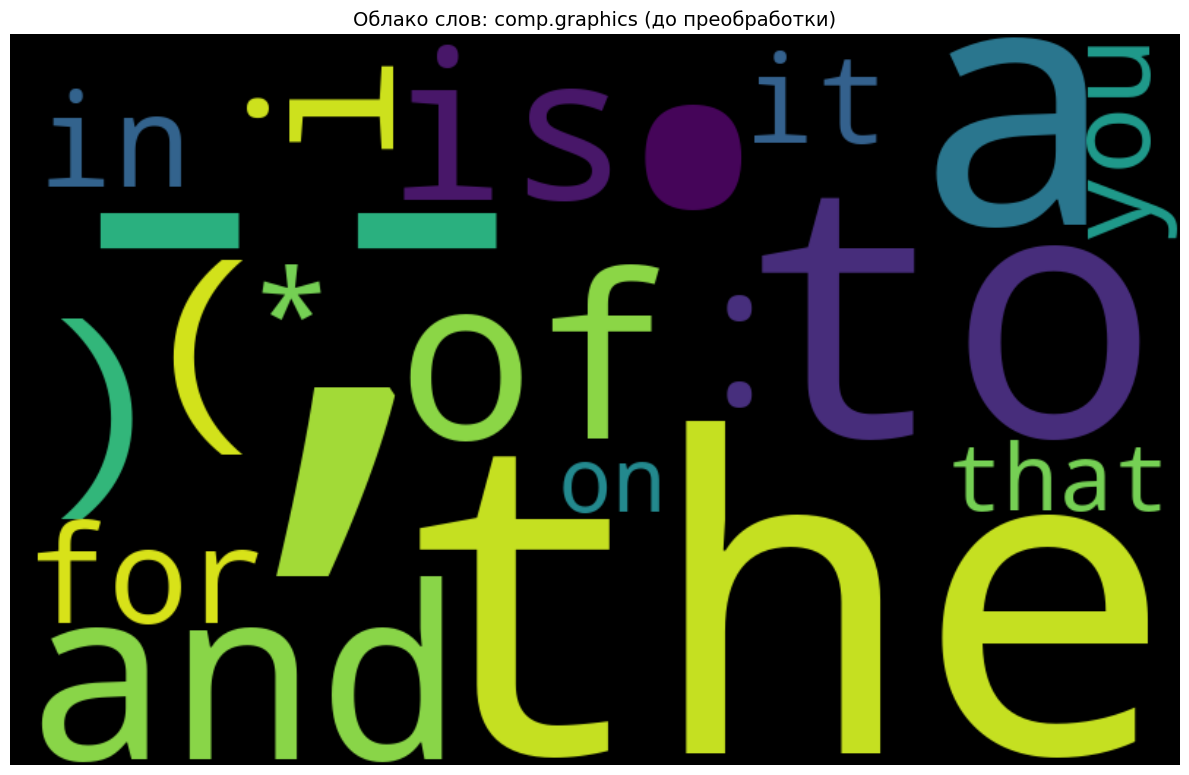

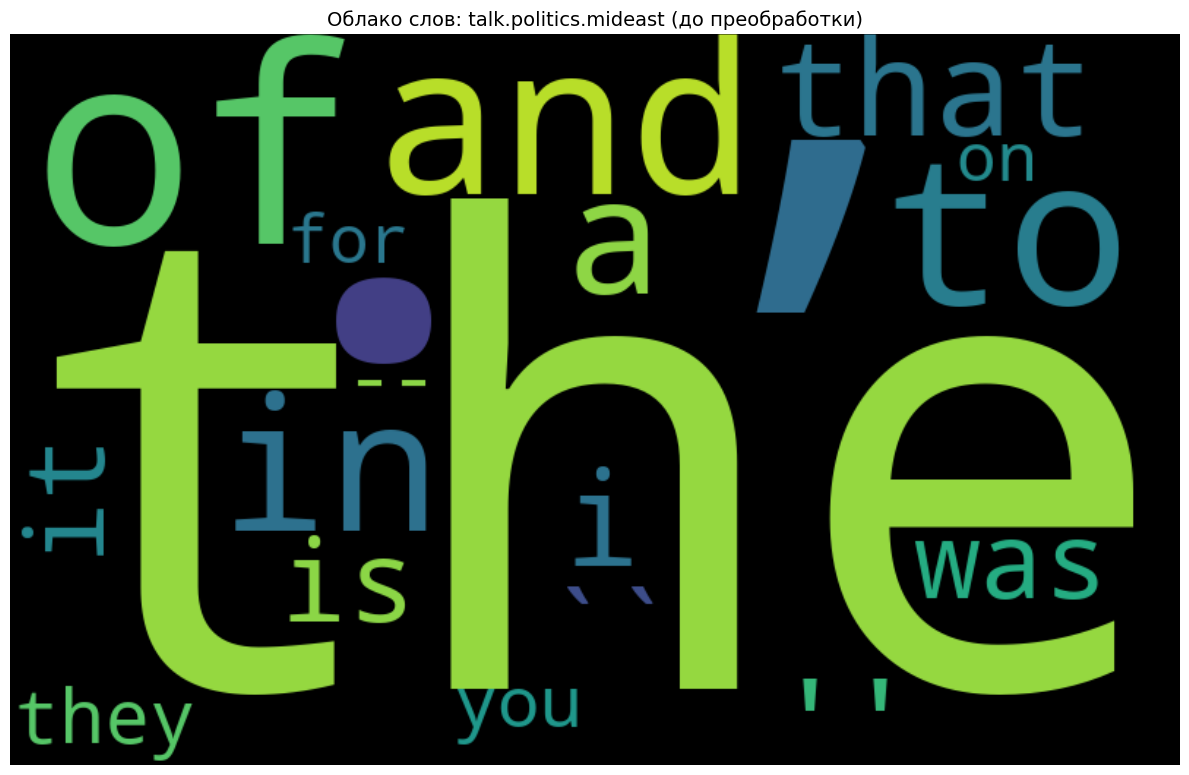

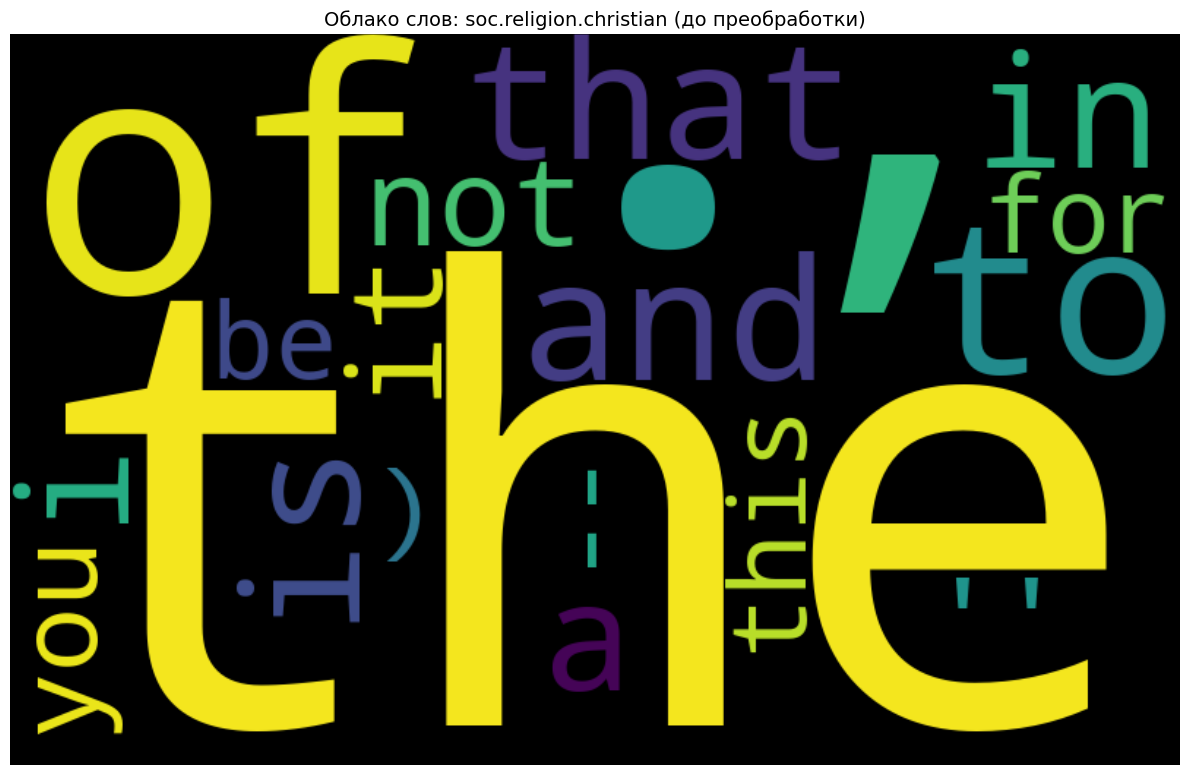

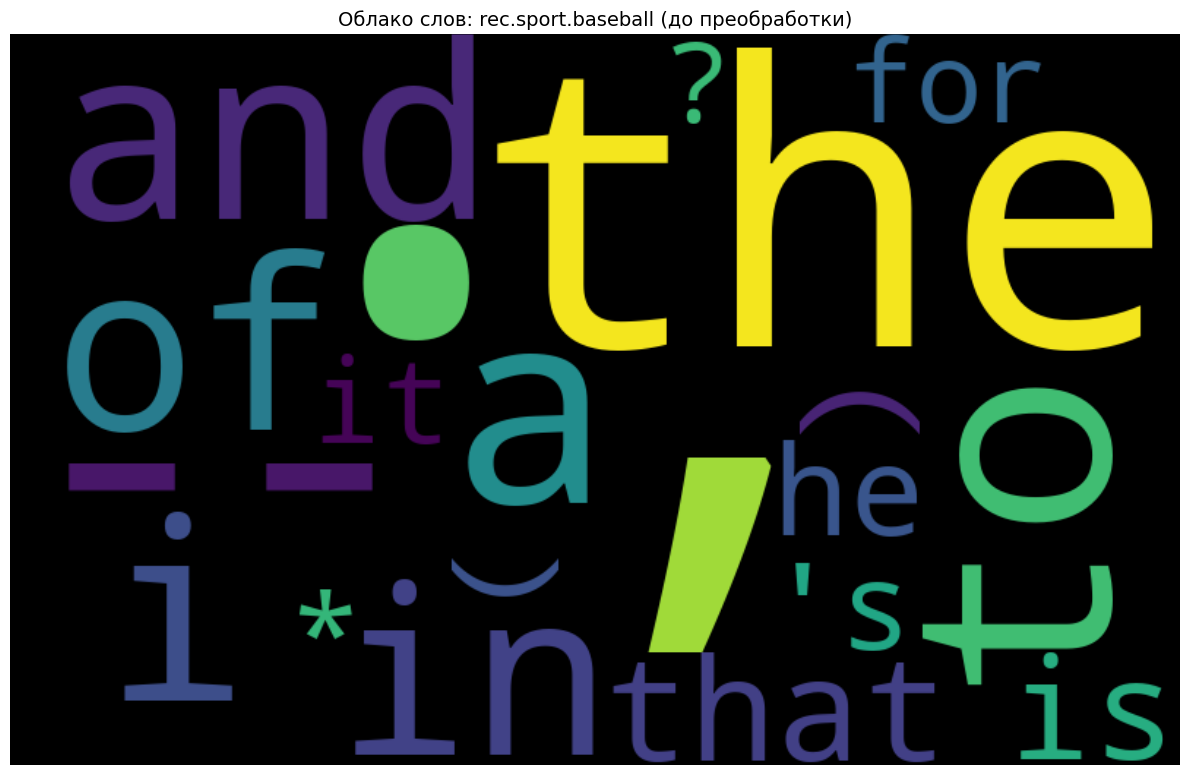

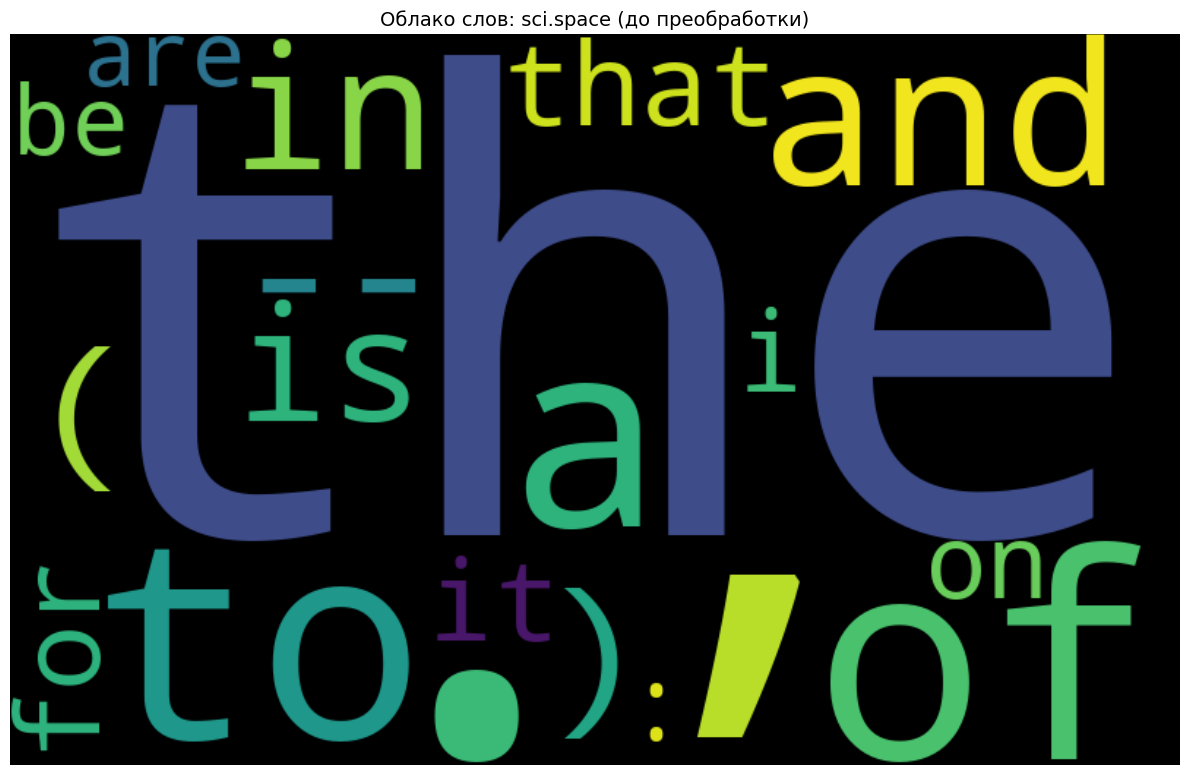

In [48]:
for class_name, words_counts in top_words_before.items():
    word_freq = dict(words_counts)
    wordcloud = WordCloud(width=800, height=500, max_words=100).generate_from_frequencies(word_freq)
    plt.figure(figsize=(12,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Облако слов: {class_name} (до преобработки)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 10. Столбчатые диаграммы ДО преобработки

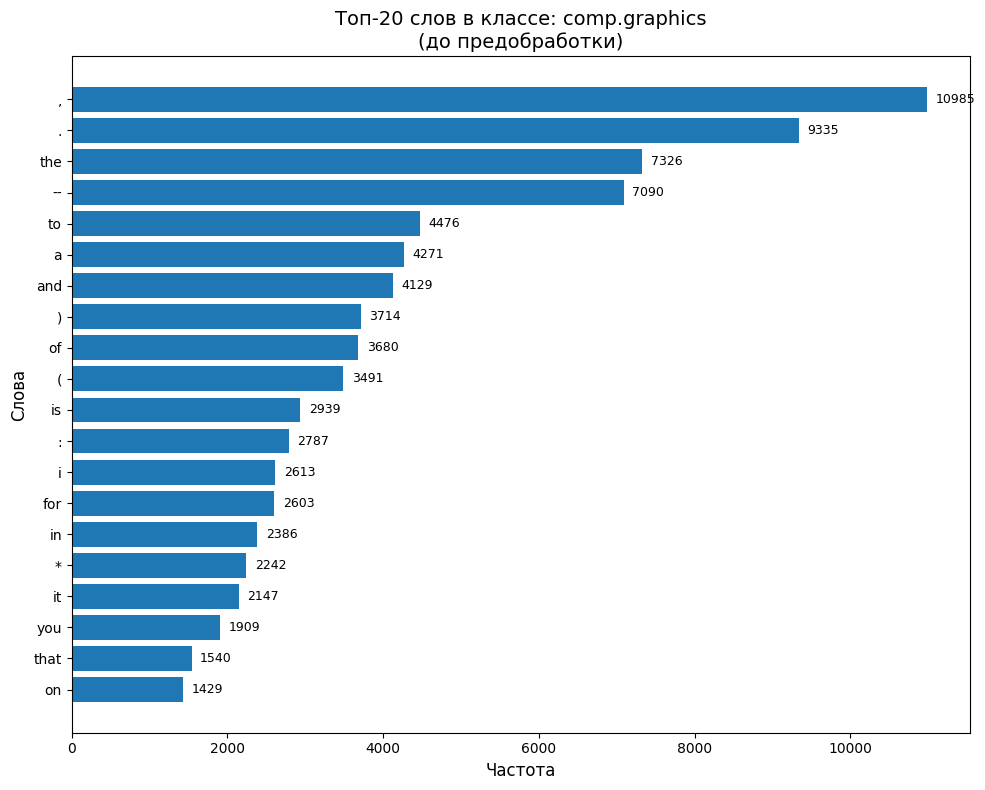

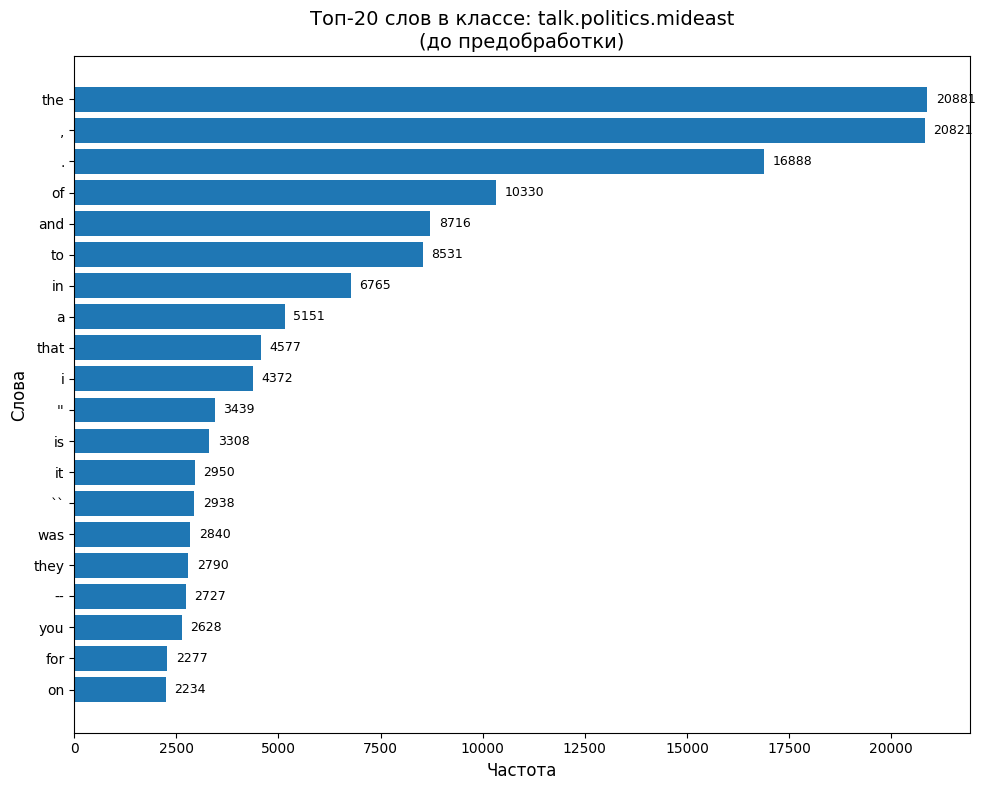

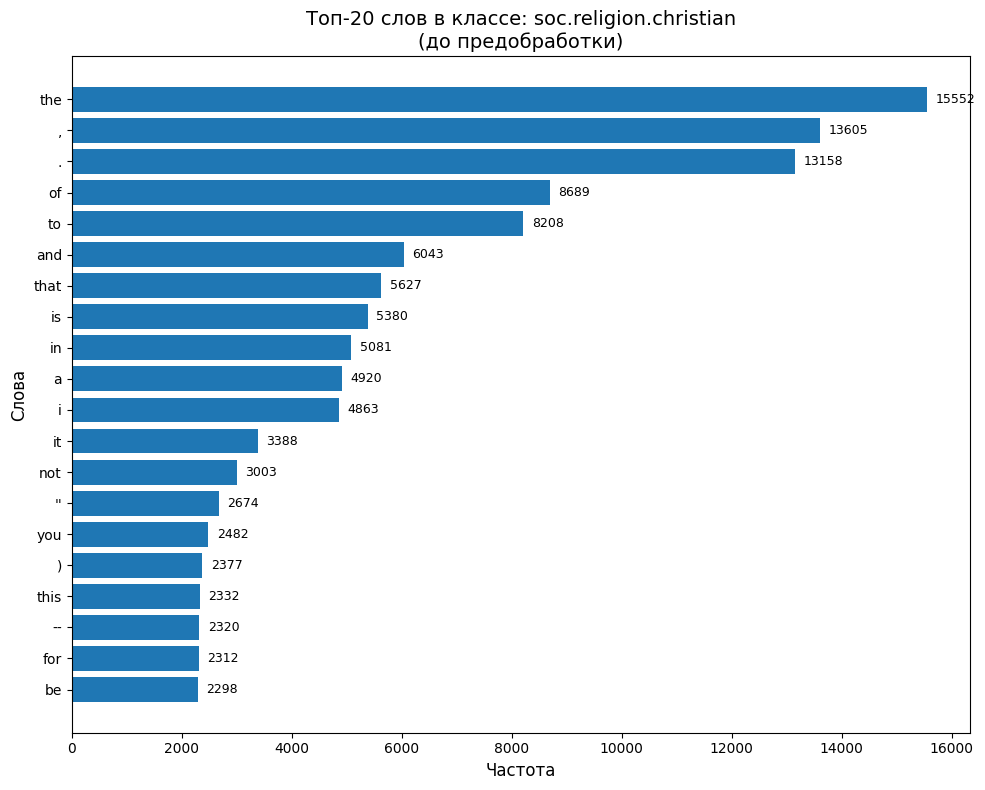

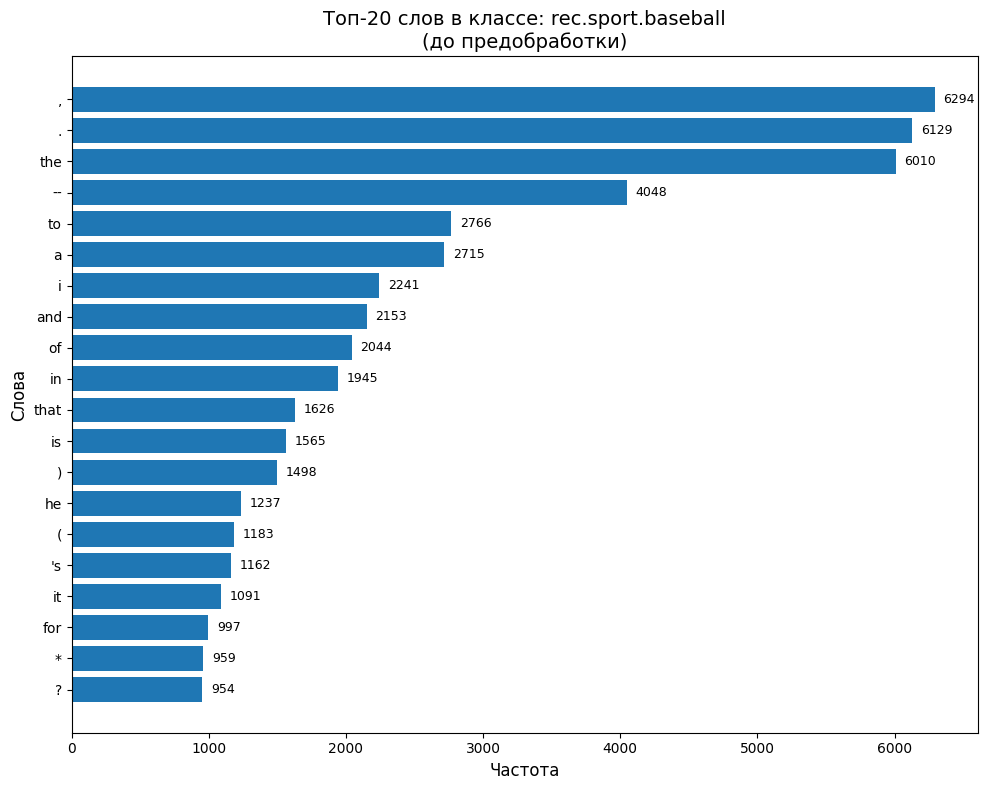

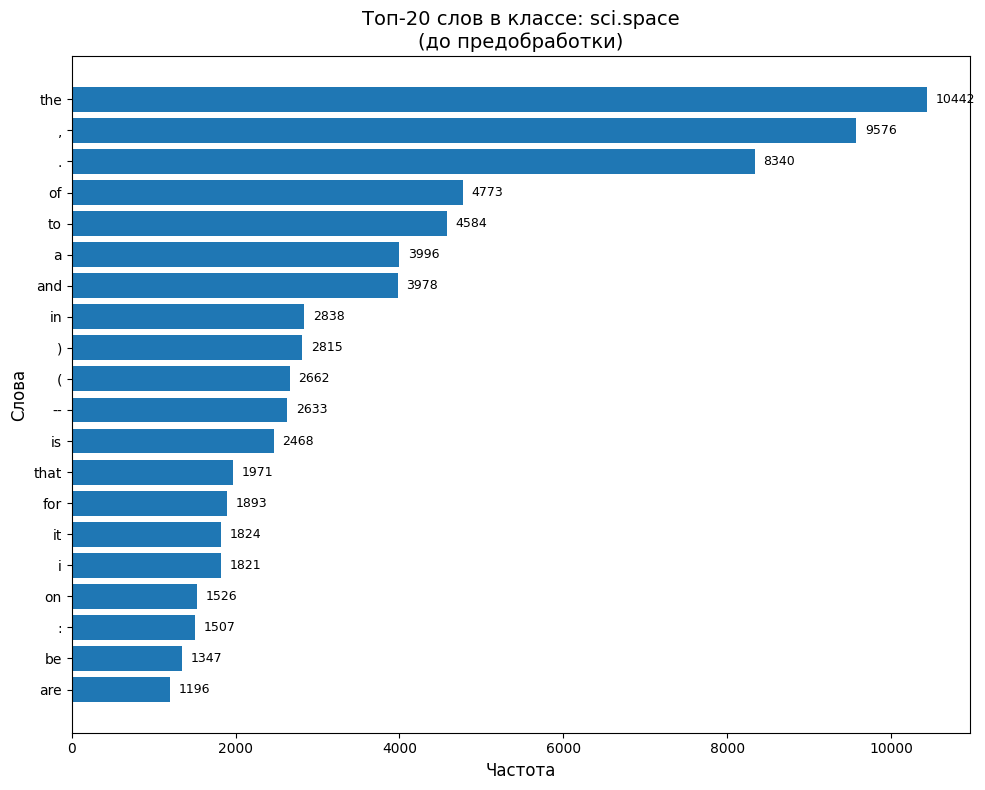

In [49]:
for class_name, words_counts in top_words_before.items():
    words=[items[0] for items in words_counts]
    counts=[items[1] for items in words_counts]
    plt.figure(figsize=(10,8))
    bars=plt.barh(words, counts)
    plt.title(f'Топ-20 слов в классе: {class_name}\n(до предобработки)', fontsize=14)
    plt.xlabel('Частота', fontsize=12)
    plt.ylabel('Слова', fontsize=12)
    plt.gca().invert_yaxis()  

    for bar, count in zip(bars, counts):
        plt.text(bar.get_width() + max(counts)*0.01, 
                 bar.get_y() + bar.get_height()/2, 
                 f'{count}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## 11. Предобработка 

In [50]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

def preprocess_text(text):
    '''
    Полный пайплайн предобработки текста:
    1. Приведение к нижнему регистру
    2. Удаление пунктуации, цифр, спецсимволов
    3. Удаление стоп-слов
    4. Лемматизация
    '''
    text=text.lower()
    text=re.sub(r'[^a-zA-Z\s]', '', text)
    text=re.sub(r'\s+',' ', text).strip()
    
    words = text.split()
    cleaned_words=[]
    for word in words:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            cleaned_words.append(lemma)
    return ' '. join(cleaned_words)

df['clean_text']=df['text'].apply(preprocess_text)
print('Предобработка завершена')
print('Исходный текст:')
print(df['text'].iloc[0][:200])
print('Обработанный текст')
print(df['clean_text'].iloc[0][:200])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\filip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\filip\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\filip\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Предобработка завершена
Исходный текст:

(1) No explicit (c) is necessary.  If it the image is attributed to the
Geosphere Company, then there is a likelihood permission is has been
given to reprint.

(2) Unlikely that the owner can or will
Обработанный текст
explicit c necessary image attributed geosphere company likelihood permission given reprint unlikely owner go individual however interesting image make way ad computer demo pirate might get flak image


## 12. Топ-20 слов ПОСЛЕ предобработки

In [51]:
def get_top_words_after(df,n=20):
    top_words={}
    for class_name in df['class_name'].unique():
        texts=df[df['class_name'] == class_name]['clean_text'].to_list()
        all_words=[]
        for text in texts:
            words = text.split()
            all_words.extend(words)
        counter=Counter(all_words)
        top_words[class_name]=counter.most_common(n)

        print(f"\n{class_name}:")
        for word, count in top_words[class_name][:20]:
            print(f" {word}:{count}")

    return top_words

top_words_after=get_top_words_after(df,n=20)


comp.graphics:
 image:1607
 file:1038
 jpeg:670
 format:627
 program:608
 graphic:592
 bit:503
 also:499
 available:454
 system:444
 software:444
 data:439
 would:438
 use:437
 color:433
 one:409
 version:394
 get:373
 display:359
 like:346

talk.politics.mideast:
 armenian:1760
 people:1195
 one:1074
 would:803
 said:772
 israel:770
 jew:731
 u:697
 turkish:658
 right:563
 muslim:559
 israeli:558
 say:554
 time:554
 arab:553
 know:545
 like:511
 dont:491
 government:461
 state:460

soc.religion.christian:
 god:1908
 one:1102
 would:1038
 christian:791
 people:765
 church:725
 jesus:680
 say:605
 know:579
 u:560
 think:543
 christ:541
 time:507
 also:491
 sin:485
 dont:485
 believe:477
 thing:462
 word:458
 like:457

rec.sport.baseball:
 game:695
 year:614
 would:465
 team:420
 one:375
 player:375
 think:338
 dont:320
 get:314
 run:313
 last:307
 hit:297
 time:292
 good:290
 like:263
 well:254
 baseball:253
 first:240
 know:223
 better:219

sci.space:
 space:1098
 would:667
 one:476
 

## 13. Облака слов ПОСЛЕ предобработки

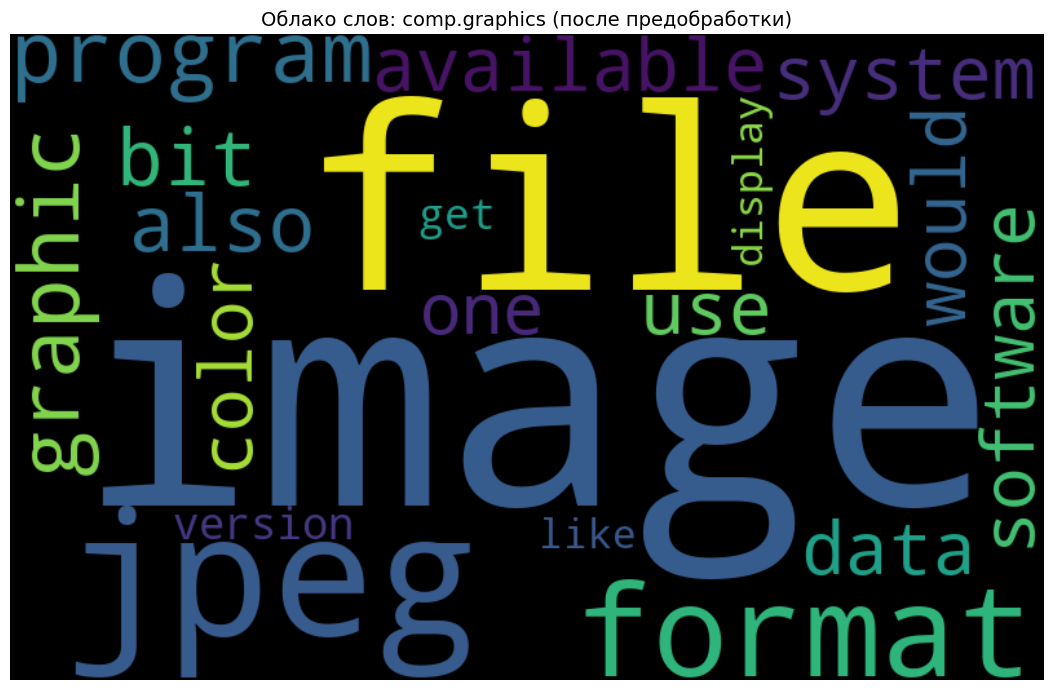

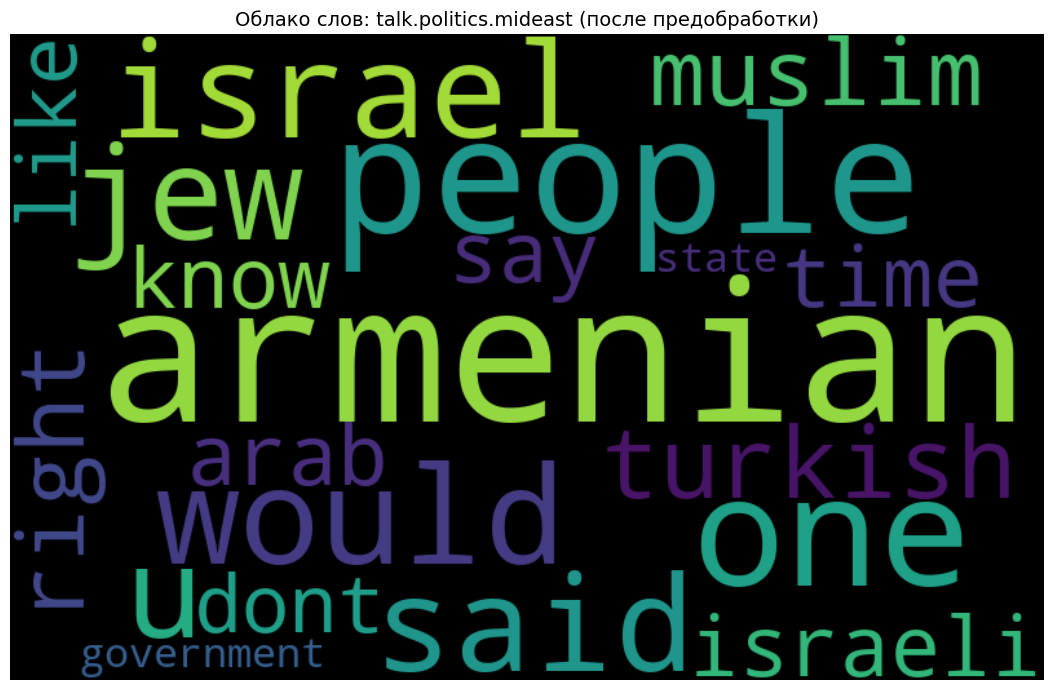

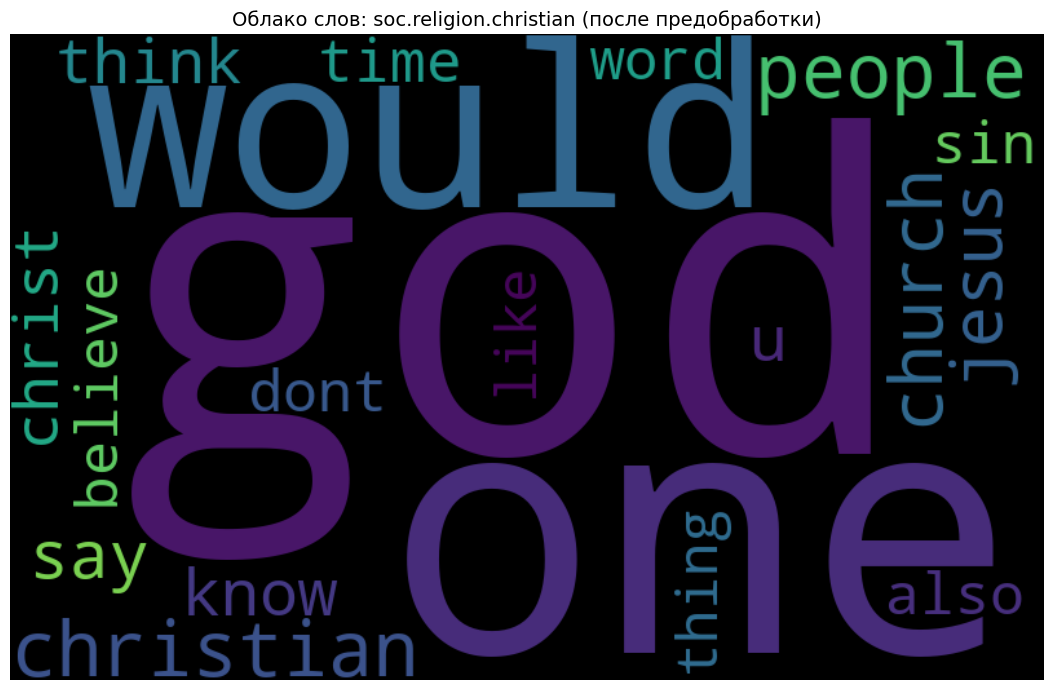

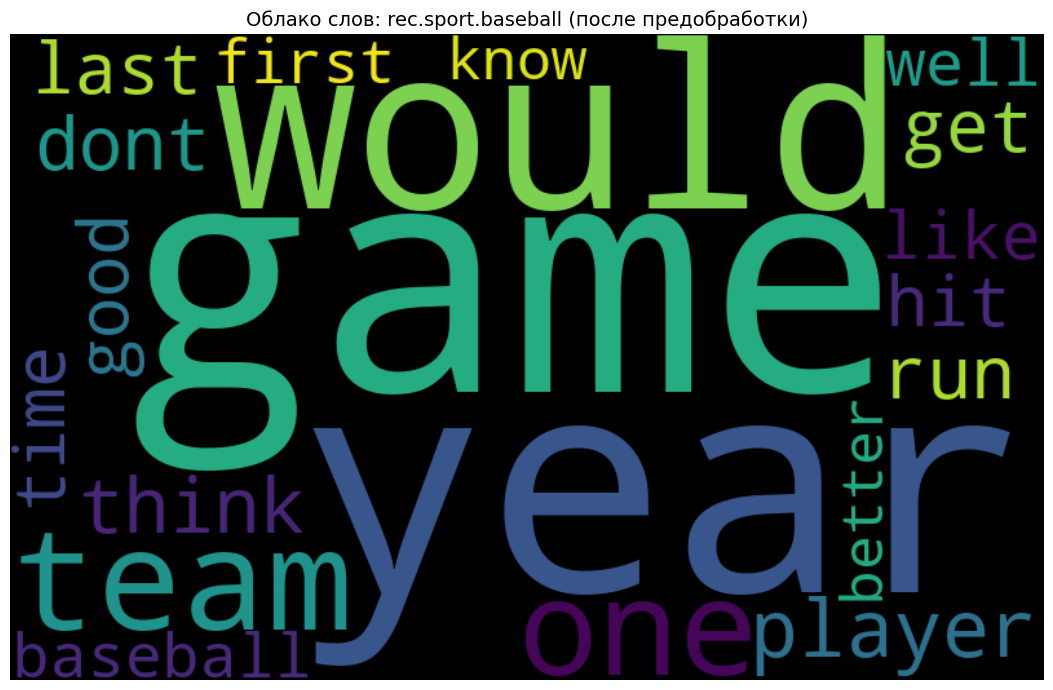

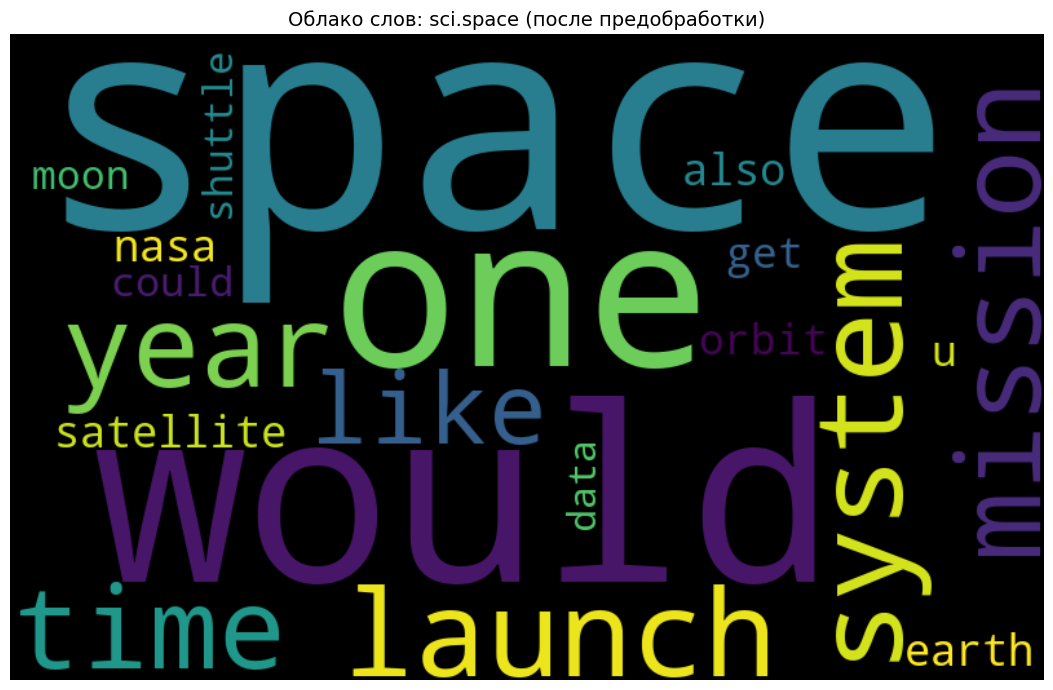

In [52]:
for class_name, words_counts in top_words_after.items():
    word_freq = dict(words_counts)    
    wordcloud = WordCloud(width=800, height=500, max_words=100
    ).generate_from_frequencies(word_freq)
    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Облако слов: {class_name} (после предобработки)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 14. Векторизация BoW, TF-IDF, Word2Vec

In [53]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

X_text = df['clean_text'].values 
y = df['target'].values  

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(X_text)
print(f"Размерность: {X_bow.shape}")

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(X_text)
print(f"Размерность: {X_tfidf.shape}")

tokenized_texts = [text.split() for text in X_text]
w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)

def get_doc_vector(words, model, vector_size=100):
    vectors = [model.wv[word] for word in words if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0) 

X_w2v = np.array([get_doc_vector(doc, w2v_model) for doc in tokenized_texts])
print(f"Размерность: {X_w2v.shape}")

Размерность: (4762, 5000)
Размерность: (4762, 5000)
Размерность: (4762, 100)


## 15. Кластеризация KMeans 

ARI: 0.2226, NMI: 0.4356

Соответствие класс - кластер:
  comp.graphics → кластер 1
  rec.sport.baseball → кластер 3
  sci.space → кластер 2
  talk.politics.mideast → кластер 0
  soc.religion.christian → кластер 2

Нормализованная матрица ошибок (%):
           comp.graphics  rec.sport.baseball  sci.space  \
Кластер 0            0.0                 0.1        0.2   
Кластер 1           68.6                 4.1        6.5   
Кластер 2           31.4                44.5       93.3   
Кластер 3            0.0                51.4        0.0   
Кластер 4            0.0                 0.0        0.0   

           talk.politics.mideast  soc.religion.christian  
Кластер 0                   61.5                     1.7  
Кластер 1                    2.9                     0.4  
Кластер 2                   35.6                    79.9  
Кластер 3                    0.0                     0.1  
Кластер 4                    0.0                    17.8  


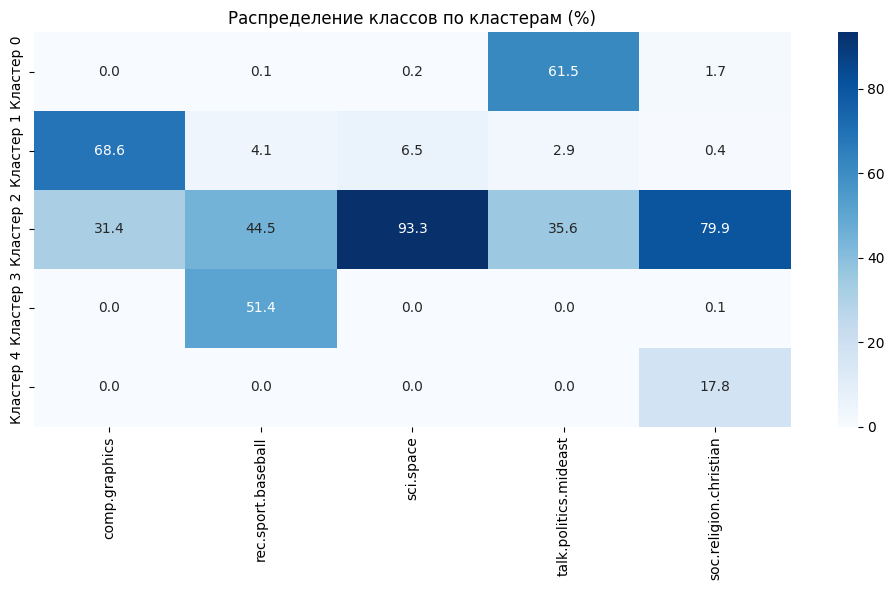

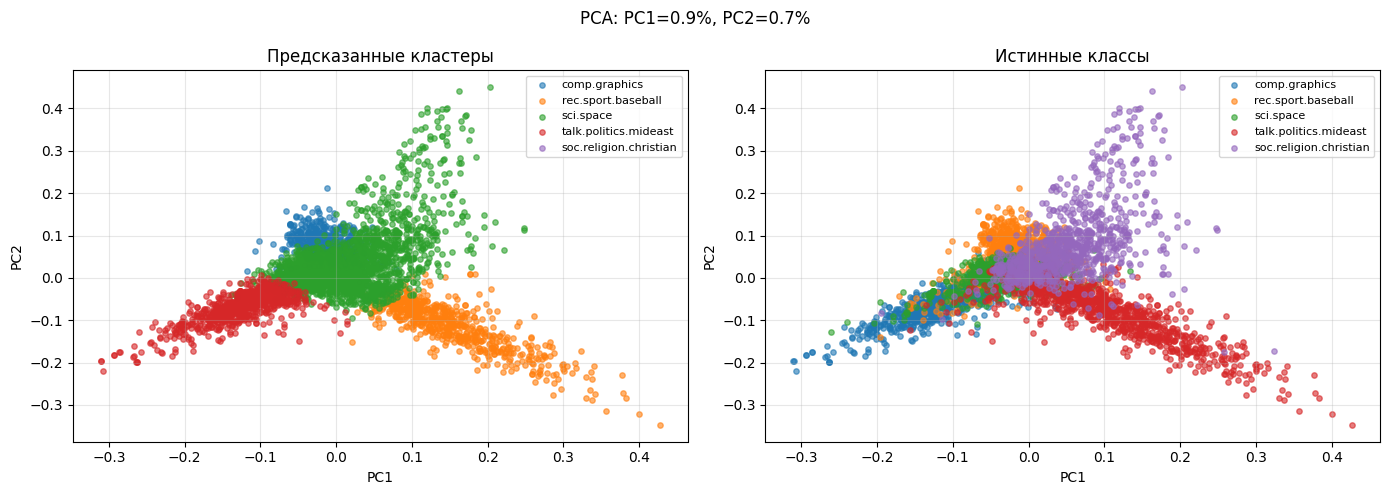

In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_tfidf)

ari = adjusted_rand_score(y, y_pred)
nmi = normalized_mutual_info_score(y, y_pred)
print(f"ARI: {ari:.4f}, NMI: {nmi:.4f}")

class_names = {0: 'comp.graphics', 1: 'rec.sport.baseball', 2: 'sci.space',
               3: 'talk.politics.mideast', 4: 'soc.religion.christian'}

class_to_cluster = {}
for class_id in range(5):
    mask = (y == class_id)
    class_to_cluster[class_id] = pd.Series(y_pred[mask]).mode()[0]

print("\nСоответствие класс - кластер:")
for class_id, cluster_id in class_to_cluster.items():
    print(f"  {class_names[class_id]} → кластер {cluster_id}")

cm = confusion_matrix(y_pred, y)
cm_norm = cm / cm.sum(axis=0) * 100
print("\nНормализованная матрица ошибок (%):")
print(pd.DataFrame(cm_norm.round(1),
                   index=[f'Кластер {i}' for i in range(5)],
                   columns=[class_names[i] for i in range(5)]))

plt.figure(figsize=(10, 6))
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_names.values(), yticklabels=[f'Кластер {i}' for i in range(5)])
plt.title('Распределение классов по кластерам (%)')
plt.tight_layout()
plt.show()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())
y_pred_mapped = np.array([class_to_cluster.get(cluster, cluster) for cluster in y_pred])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for class_id in range(5):
    axes[0].scatter(X_pca[y_pred_mapped == class_id, 0], X_pca[y_pred_mapped == class_id, 1],
                    c=colors[class_id], label=class_names[class_id], alpha=0.6, s=15)
    axes[1].scatter(X_pca[y == class_id, 0], X_pca[y == class_id, 1],
                    c=colors[class_id], label=class_names[class_id], alpha=0.6, s=15)

axes[0].set_title('Предсказанные кластеры')
axes[1].set_title('Истинные классы')
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)

ev = pca.explained_variance_ratio_
fig.suptitle(f'PCA: PC1={ev[0]:.1%}, PC2={ev[1]:.1%}')
plt.tight_layout()
plt.show()

## 16. Бинарная кластеризация space vs religion

In [56]:
mask = (df['class_name'] == 'sci.space') | (df['class_name'] == 'soc.religion.christian')
X_bin = df[mask]['clean_text'].values
y_bin = df[mask]['target'].values
y_bin_01 = (y_bin == 2).astype(int) 

print(f"Документов space: {sum(y_bin == 2)}, religion: {sum(y_bin == 3)}")

tfidf_bin = TfidfVectorizer(max_features=5000)
X_bin_tfidf = tfidf_bin.fit_transform(X_bin)

kmeans_bin = KMeans(n_clusters=2, random_state=42, n_init=10)
y_pred_bin = kmeans_bin.fit_predict(X_bin_tfidf)

ari_bin = adjusted_rand_score(y_bin_01, y_pred_bin)
print(f"ARI: {ari_bin:.4f}")

cm_bin = confusion_matrix(y_bin_01, y_pred_bin)
cm_bin_norm = cm_bin / cm_bin.sum(axis=1)[:, np.newaxis] * 100
print("\nНормализованная матрица ошибок (%):")
print(pd.DataFrame(cm_bin_norm,
                   index=['religion', 'space'],
                   columns=['Кластер 0', 'Кластер 1']))

Документов space: 955, religion: 975
ARI: 0.4205

Нормализованная матрица ошибок (%):
          Кластер 0  Кластер 1
religion  34.666667  65.333333
space     99.895288   0.104712


## 17. Разделение train/test

In [57]:
from sklearn.model_selection import train_test_split

X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42, stratify=y)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=42, stratify=y)

_, X_test_text, _, _ = train_test_split(df['clean_text'], y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
print(f"BoW train: {X_train_bow.shape}, test: {X_test_bow.shape}")
print(f"TF-IDF train: {X_train_tfidf.shape}, test: {X_test_tfidf.shape}")
print(f"Word2Vec train: {X_train_w2v.shape}, test: {X_test_w2v.shape}")

Train size: 3809, Test size: 953
BoW train: (3809, 5000), test: (953, 5000)
TF-IDF train: (3809, 5000), test: (953, 5000)
Word2Vec train: (3809, 100), test: (953, 100)


## 18. Классификация на TF‑IDF + GridSearch (LR, SVM, RF, XGB)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

lr = LogisticRegression(random_state=42, max_iter=1000)
param_grid = {
    'C': [0.1, 1, 10]
}
grid_lr = GridSearchCV(lr, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train_tfidf, y_train)

print("Лучшие параметры:", grid_lr.best_params_)
print("Лучшее CV качество (F1-macro):", grid_lr.best_score_)

y_pred = grid_lr.predict(X_test_tfidf)

print("\nОценка на тестовой выборке")
print(f"F1-macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")

from sklearn.svm import SVC
svm = SVC(random_state=42)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='f1_macro', n_jobs=-1)
grid_svm.fit(X_train_tfidf, y_train)
print("SVM - лучшие параметры:", grid_svm.best_params_)
print("SVM - лучшее CV качество:", grid_svm.best_score_)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='f1_macro', n_jobs=-1)  # cv=3 для скорости
grid_rf.fit(X_train_tfidf, y_train)
print("RandomForest - лучшие параметры:", grid_rf.best_params_)
print("RandomForest - лучшее CV качество:", grid_rf.best_score_)

from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.3]
}
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring='f1_macro', n_jobs=-1)
grid_xgb.fit(X_train_tfidf, y_train)
print("XGBoost - лучшие параметры:", grid_xgb.best_params_)
print("XGBoost - лучшее CV качество:", grid_xgb.best_score_)

models = {
    'LogisticRegression': grid_lr,
    'SVM': grid_svm,
    'RandomForest': grid_rf,
    'XGBoost': grid_xgb
}

results = []

for name, grid in models.items():
    y_pred = grid.predict(X_test_tfidf)
    
    results.append({
        'Модель': name,
        'Лучшие параметры': str(grid.best_params_),
        'CV F1-macro': round(grid.best_score_, 4),
        'Test F1-macro': round(f1_score(y_test, y_pred, average='macro'), 4),
        'Test F1-weighted': round(f1_score(y_test, y_pred, average='weighted'), 4)
    })

results_df = pd.DataFrame(results)
print("\nРезультаты (TF-IDF)")
print(results_df.to_string(index=False))

Лучшие параметры: {'C': 1}
Лучшее CV качество (F1-macro): 0.8975954640291623

Оценка на тестовой выборке
F1-macro: 0.9072
F1-weighted: 0.9075
SVM - лучшие параметры: {'C': 10, 'kernel': 'rbf'}
SVM - лучшее CV качество: 0.895558101173893
RandomForest - лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
RandomForest - лучшее CV качество: 0.8531017845341697
XGBoost - лучшие параметры: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}
XGBoost - лучшее CV качество: 0.8503019074563719

Результаты (TF-IDF)
            Модель                                                 Лучшие параметры  CV F1-macro  Test F1-macro  Test F1-weighted
LogisticRegression                                                         {'C': 1}       0.8976         0.9072            0.9075
               SVM                                       {'C': 10, 'kernel': 'rbf'}       0.8956         0.9030            0.9033
      RandomForest {'max_depth': None, 'min_samples_split': 5, 

## 19. Классификация на BoW

In [59]:
print('LogisticRegression on BoW')
lr_bow = LogisticRegression(random_state=42, max_iter=100)
param_grid_lr = {'C': [0.1, 1, 10]}

grid_lr = GridSearchCV(lr_bow, param_grid_lr, cv=5, scoring='f1_macro', n_jobs=-1)
grid_lr.fit(X_train_bow, y_train)

print(f"Лучшие параметры: {grid_lr.best_params_}")
print(f"CV F1-macro: {grid_lr.best_score_:.4f}")

y_pred = grid_lr.predict(X_test_bow)
print(f"Test F1-macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Test F1-weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print('SVC on BoW')

svm = SVC(random_state=42)
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='f1_macro', n_jobs=-1)
grid_svm.fit(X_train_bow, y_train)

print(f"Лучшие параметры: {grid_svm.best_params_}")
print(f"CV F1-macro: {grid_svm.best_score_:.4f}")

y_pred = grid_svm.predict(X_test_bow)
print(f"Test F1-macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Test F1-weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print('Random Forest on BoW')

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train_bow, y_train)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"CV F1-macro: {grid_rf.best_score_:.4f}")

y_pred = grid_rf.predict(X_test_bow)
print(f"Test F1-macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Test F1-weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print('XGBoost on BoW')

xgb = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.3]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring='f1_macro', n_jobs=-1)
grid_xgb.fit(X_train_bow, y_train)

print(f"Лучшие параметры: {grid_xgb.best_params_}")
print(f"CV F1-macro: {grid_xgb.best_score_:.4f}")

y_pred = grid_xgb.predict(X_test_bow)
print(f"Test F1-macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Test F1-weighted: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print('Таблица результатов (BoW)')

results_bow = pd.DataFrame([
    {'Модель': 'LogisticRegression', 
     'CV F1-macro': grid_lr.best_score_,
     'Test F1-macro': f1_score(y_test, grid_lr.predict(X_test_bow), average='macro'),
     'Test F1-weighted': f1_score(y_test, grid_lr.predict(X_test_bow), average='weighted')},
    
    {'Модель': 'SVM', 
     'CV F1-macro': grid_svm.best_score_,
     'Test F1-macro': f1_score(y_test, grid_svm.predict(X_test_bow), average='macro'),
     'Test F1-weighted': f1_score(y_test, grid_svm.predict(X_test_bow), average='weighted')},
    
    {'Модель': 'RandomForest', 
     'CV F1-macro': grid_rf.best_score_,
     'Test F1-macro': f1_score(y_test, grid_rf.predict(X_test_bow), average='macro'),
     'Test F1-weighted': f1_score(y_test, grid_rf.predict(X_test_bow), average='weighted')},
    
    {'Модель': 'XGBoost', 
     'CV F1-macro': grid_xgb.best_score_,
     'Test F1-macro': f1_score(y_test, grid_xgb.predict(X_test_bow), average='macro'),
     'Test F1-weighted': f1_score(y_test, grid_xgb.predict(X_test_bow), average='weighted')}
])

print(results_bow.round(4).to_string(index=False))

LogisticRegression on BoW
Лучшие параметры: {'C': 0.1}
CV F1-macro: 0.8718
Test F1-macro: 0.8779
Test F1-weighted: 0.8781
SVC on BoW
Лучшие параметры: {'C': 0.1, 'kernel': 'linear'}
CV F1-macro: 0.8294
Test F1-macro: 0.8454
Test F1-weighted: 0.8456
Random Forest on BoW
Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
CV F1-macro: 0.8580
Test F1-macro: 0.8502
Test F1-weighted: 0.8505
XGBoost on BoW
Лучшие параметры: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}
CV F1-macro: 0.8542
Test F1-macro: 0.8510
Test F1-weighted: 0.8512
Таблица результатов (BoW)
            Модель  CV F1-macro  Test F1-macro  Test F1-weighted
LogisticRegression       0.8718         0.8779            0.8781
               SVM       0.8294         0.8454            0.8456
      RandomForest       0.8580         0.8502            0.8505
           XGBoost       0.8542         0.8510            0.8512


## 20. Классификация на Word2Vec

In [60]:
print("Word2Vec Classification")

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import pandas as pd

results_w2v = []

print("\n1. Logistic Regression on Word2Vec")
lr = LogisticRegression(C=1, random_state=42, max_iter=1000)
lr.fit(X_train_w2v, y_train)
y_pred = lr.predict(X_test_w2v)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
results_w2v.append(['LogisticRegression', f1_macro, f1_weighted])
print(f"Test F1-macro: {f1_macro:.4f}")
print(f"Test F1-weighted: {f1_weighted:.4f}")

print("\n2. SVM on Word2Vec")
svm = SVC(C=10, kernel='rbf', random_state=42)
svm.fit(X_train_w2v, y_train)
y_pred = svm.predict(X_test_w2v)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
results_w2v.append(['SVM', f1_macro, f1_weighted])
print(f"Test F1-macro: {f1_macro:.4f}")
print(f"Test F1-weighted: {f1_weighted:.4f}")

print("\n3. Random Forest on Word2Vec")
rf = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train_w2v, y_train)
y_pred = rf.predict(X_test_w2v)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
results_w2v.append(['RandomForest', f1_macro, f1_weighted])
print(f"Test F1-macro: {f1_macro:.4f}")
print(f"Test F1-weighted: {f1_weighted:.4f}")

print("\n4. XGBoost on Word2Vec")
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.3, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_w2v, y_train)
y_pred = xgb.predict(X_test_w2v)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
results_w2v.append(['XGBoost', f1_macro, f1_weighted])
print(f"Test F1-macro: {f1_macro:.4f}")
print(f"Test F1-weighted: {f1_weighted:.4f}")

print("Сводная таблица (Word2Vec)")
results_w2v_df = pd.DataFrame(results_w2v, columns=['Модель', 'Test F1-macro', 'Test F1-weighted'])
print(results_w2v_df.round(4).to_string(index=False))

Word2Vec Classification

1. Logistic Regression on Word2Vec
Test F1-macro: 0.8327
Test F1-weighted: 0.8330

2. SVM on Word2Vec
Test F1-macro: 0.8376
Test F1-weighted: 0.8380

3. Random Forest on Word2Vec
Test F1-macro: 0.8168
Test F1-weighted: 0.8172

4. XGBoost on Word2Vec
Test F1-macro: 0.8276
Test F1-weighted: 0.8279
Сводная таблица (Word2Vec)
            Модель  Test F1-macro  Test F1-weighted
LogisticRegression         0.8327            0.8330
               SVM         0.8376            0.8380
      RandomForest         0.8168            0.8172
           XGBoost         0.8276            0.8279


## 21. Анализ ошибок (матрица + топ-10 ошибок)

In [61]:
misclassified_idx = np.where(y_test != y_pred_best)[0]
print(f"Всего ошибок: {len(misclassified_idx)} из {len(y_test)} ({len(misclassified_idx)/len(y_test)*100:.1f}%)")

y_proba = best_model.predict_proba(X_test_tfidf)
y_max_proba = np.max(y_proba, axis=1)

errors_info = []
for idx in misclassified_idx:
    true_class = y_test[idx]
    pred_class = y_pred_best[idx]
    confidence = y_max_proba[idx]
    
    text_fragment = X_test_text.iloc[idx][:300]
    
    errors_info.append({
        'index': idx,
        'true_class': class_names[true_class],
        'pred_class': class_names[pred_class],
        'confidence': confidence,
        'text': text_fragment
    })

errors_info.sort(key=lambda x: x['confidence'], reverse=True)

print("\nТоп-10 ошибок\n")
for i, err in enumerate(errors_info[:10]):
    print(f"Ошибка {i+1}:")
    print(f"Истинный класс:{err['true_class']}")
    print(f"Предсказанный класс:{err['pred_class']}")
    print(f"Уверенность модели:{err['confidence']:.2%}")
    print(f"Текст (первые 300 символов):")
    print(f"{err['text'][:300]}...")
    print()

Всего ошибок: 276 из 953 (29.0%)

Топ-10 ошибок

Ошибка 1:
Истинный класс:comp.graphics
Предсказанный класс:rec.sport.baseball
Уверенность модели:35.06%
Текст (первые 300 символов):
could someone please post list good threed modeler run sparc station preferably cheap thanks...

Ошибка 2:
Истинный класс:soc.religion.christian
Предсказанный класс:rec.sport.baseball
Уверенность модели:32.52%
Текст (первые 300 символов):
thing university fun may admit partying go consistently ranked one playboy top party school study importantly learn lot overall uva drug use actually lower average college u hate law book even though force pc tried one last year way similar law university wisconsin found unconstitutional last year l...

Ошибка 3:
Истинный класс:soc.religion.christian
Предсказанный класс:comp.graphics
Уверенность модели:31.80%
Текст (первые 300 символов):
dear friend hi need information organization ofislamic conference oic anyone know book article journal contains information regarding org

## 22. Бинарная классификация space vs religion

In [62]:
print("Бинарная классификация: sci.space vs soc.religion.christian")
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np

mask_binary = (df['class_name'] == 'sci.space') | (df['class_name'] == 'soc.religion.christian')
X_binary = df[mask_binary]['clean_text'].values
y_binary = df[mask_binary]['target'].values

space_target = df[df['class_name'] == 'sci.space']['target'].iloc[0]
print(f"Метка sci.space: {space_target}")

y_binary_01 = (y_binary == space_target).astype(int)

print(f"\nДокументов sci.space: {sum(y_binary_01 == 1)}")
print(f"Документов soc.religion: {sum(y_binary_01 == 0)}")
print(f"Всего документов: {len(y_binary_01)}")

tfidf = TfidfVectorizer(max_features=5000)
X_binary_tfidf = tfidf.fit_transform(X_binary)
X_train, X_test, y_train, y_test = train_test_split(
    X_binary_tfidf, y_binary_01, test_size=0.2, random_state=42, stratify=y_binary_01
)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

print("1. Логистическая регрессия")
lr = LogisticRegression(C=1, random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['religion', 'space']))

print("2. SVM")
svm = SVC(C=10, kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['religion', 'space']))

print("3. Random forest")
rf = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['religion', 'space']))

print("Свобдная таблица результатов (space vs religion)")
results = pd.DataFrame([
    {'Модель': 'LogisticRegression', 
     'Accuracy': accuracy_score(y_test, y_pred_lr),
     'Precision': precision_score(y_test, y_pred_lr),
     'Recall': recall_score(y_test, y_pred_lr),
     'F1': f1_score(y_test, y_pred_lr)},
    
    {'Модель': 'SVM', 
     'Accuracy': accuracy_score(y_test, y_pred_svm),
     'Precision': precision_score(y_test, y_pred_svm),
     'Recall': recall_score(y_test, y_pred_svm),
     'F1': f1_score(y_test, y_pred_svm)},
    
    {'Модель': 'RandomForest', 
     'Accuracy': accuracy_score(y_test, y_pred_rf),
     'Precision': precision_score(y_test, y_pred_rf),
     'Recall': recall_score(y_test, y_pred_rf),
     'F1': f1_score(y_test, y_pred_rf)}
])
print(results.round(4).to_string(index=False))

print("Вывод:")
best_f1_binary = results['F1'].max()
print(f"Лучший F1-score для бинарной классификации: {best_f1_binary:.4f}")
print(f"F1-score для классификации на 5 классах: 0.9072")
print(f"Разница: {best_f1_binary - 0.9072:.4f}")


Бинарная классификация: sci.space vs soc.religion.christian
Метка sci.space: 2

Документов sci.space: 955
Документов soc.religion: 975
Всего документов: 1930

Размер обучающей выборки: 1544
Размер тестовой выборки: 386
1. Логистическая регрессия
Accuracy:  0.9585
Precision: 0.9397
Recall:    0.9791
F1-score:  0.9590

Classification Report:
              precision    recall  f1-score   support

    religion       0.98      0.94      0.96       195
       space       0.94      0.98      0.96       191

    accuracy                           0.96       386
   macro avg       0.96      0.96      0.96       386
weighted avg       0.96      0.96      0.96       386

2. SVM
Accuracy:  0.9637
Precision: 0.9492
Recall:    0.9791
F1-score:  0.9639

Classification Report:
              precision    recall  f1-score   support

    religion       0.98      0.95      0.96       195
       space       0.95      0.98      0.96       191

    accuracy                           0.96       386
   macro a

## 23. Влияние дисбаланса

In [63]:
print("Исследование влияния дисбаланса классов")
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import numpy as np

X = X_tfidf
y_target = y
print("\n1. Создание несбалансированной выборки")
unique, counts = np.unique(y_target, return_counts=True)
min_class = unique[np.argmin(counts)]
print(f"Самый маленький класс: {class_names[min_class]}, {counts.min()} документов")

target_class = 4
original_size = sum(y_target == target_class)
new_size = original_size // 5

indices = np.where(y_target == target_class)[0]
undersampled = resample(indices, replace=False, n_samples=new_size, random_state=42)

indices_imb = np.concatenate([np.where(y_target != target_class)[0], undersampled])
X_imb = X[indices_imb]
y_imb = y_target[indices_imb]

print(f"Размер сбалансированной выборки: {X.shape[0]}")
print(f"Размер НЕсбалансированной выборки: {X_imb.shape[0]}")
print(f"Класс {class_names[target_class]} уменьшен с {original_size} до {new_size}")

print("\n2. Обучение на несбалансированных данных")
from sklearn.model_selection import train_test_split
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)

lr_imb = LogisticRegression(C=1, random_state=42, max_iter=1000)
lr_imb.fit(X_train_imb, y_train_imb)
y_pred_imb = lr_imb.predict(X_test_imb)
f1_imb = f1_score(y_test_imb, y_pred_imb, average='macro')

print(f"F1-macro на сбалансированных данных: 0.9072")
print(f"F1-macro на несбарансированных данных: {f1_imb:.4f}")
print(f"Падение качества: {0.9072 - f1_imb:.4f}")

print("\n3. Метод борьбы: взвешивание классов")

lr_weighted = LogisticRegression(C=1, class_weight='balanced', random_state=42, max_iter=1000)
lr_weighted.fit(X_train_imb, y_train_imb)
y_pred_weighted = lr_weighted.predict(X_test_imb)
f1_weighted = f1_score(y_test_imb, y_pred_weighted, average='macro')

print(f"F1-macro с весами классов: {f1_weighted:.4f}")
print(f"Улучшение: {f1_weighted - f1_imb:.4f}")

print("\n4. Метод борьбы: oversampling")

indices_class4 = np.where(y_train_imb == target_class)[0]
oversampled = resample(indices_class4, replace=True, n_samples=original_size, random_state=42)

X_train_balanced = np.vstack([X_train_imb.toarray(), X_train_imb[oversampled].toarray()])
y_train_balanced = np.concatenate([y_train_imb, y_train_imb[oversampled]])

lr_oversample = LogisticRegression(C=1, random_state=42, max_iter=1000)
lr_oversample.fit(X_train_balanced, y_train_balanced)
y_pred_oversample = lr_oversample.predict(X_test_imb)
f1_oversample = f1_score(y_test_imb, y_pred_oversample, average='macro')

print(f"F1-macro с Oversampling: {f1_oversample:.4f}")
print(f"Улучшение: {f1_oversample - f1_imb:.4f}")

print("Вывод:")
print(f"Без борьбы с дисбалансом:   F1 = {f1_imb:.4f}")
print(f"Взвешивание классов:        F1 = {f1_weighted:.4f}")
print(f"Oversampling:               F1 = {f1_oversample:.4f}")
print(f"Сбалансированные данные:    F1 = 0.9072")

if f1_weighted > f1_imb or f1_oversample > f1_imb:
    print("\nМетоды борьбы с дисбалансом улучшили качество классификации.")
else:
    print("\nДисбаланс был незначительным, улучшение минимально.")

Исследование влияния дисбаланса классов

1. Создание несбалансированной выборки
Самый маленький класс: soc.religion.christian, 919 документов
Размер сбалансированной выборки: 4762
Размер НЕсбалансированной выборки: 4026
Класс soc.religion.christian уменьшен с 919 до 183

2. Обучение на несбалансированных данных
F1-macro на сбалансированных данных: 0.9072
F1-macro на несбарансированных данных: 0.8657
Падение качества: 0.0415

3. Метод борьбы: взвешивание классов
F1-macro с весами классов: 0.9206
Улучшение: 0.0549

4. Метод борьбы: oversampling
F1-macro с Oversampling: 0.9164
Улучшение: 0.0506
Вывод:
Без борьбы с дисбалансом:   F1 = 0.8657
Взвешивание классов:        F1 = 0.9206
Oversampling:               F1 = 0.9164
Сбалансированные данные:    F1 = 0.9072

Методы борьбы с дисбалансом улучшили качество классификации.


## 24. Ансамбль классификаторов

In [65]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

X_train_ens, X_test_ens, y_train_ens, y_test_ens = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("\n1. Создание ансамбля (VotingClassifier)")

lr_ens = LogisticRegression(C=1, random_state=42, max_iter=1000)
svm_ens = SVC(C=10, kernel='rbf', probability=True, random_state=42)
xgb_ens = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, 
                        random_state=42, eval_metric='mlogloss')

ensemble = VotingClassifier(
    estimators=[('lr', lr_ens), ('svm', svm_ens), ('xgb', xgb_ens)],
    voting='soft'
)

print("\n2. Обучение и оценка")

ensemble.fit(X_train_ens, y_train_ens)
y_pred_ens = ensemble.predict(X_test_ens)

f1_ens = f1_score(y_test_ens, y_pred_ens, average='macro')

print(f"Ансамбль (LR + SVM + XGB): F1-macro = {f1_ens:.4f}")
print(f"Лучшая индивидуальная модель (LR): F1-macro = 0.9072")
print(f"Разница: {f1_ens - 0.9072:.4f}")

print("\n3. Обоснование выбора")
print("""
В ансамбль включены три разнородных классификатора:
1. Логистическая регрессия (линейная) — хорошо работает с разреженными данными
2. SVM (ядерный) — эффективен в высокой размерности
3. XGBoost (градиентный бустинг) — учитывает взаимодействия признаков
      Разнородность позволяет ансамблю компенсировать ошибки отдельных моделей.
""")

print("Вывод по пункту 9")

if f1_ens > 0.9072:
    print(f"Ансамбль показал лучший результат: F1 = {f1_ens:.4f} (>0.9072)")
    print("Причина: модели компенсируют ошибки друг друга.")
else:
    print(f"Ансамбль не превзошел лучшую модель: F1 = {f1_ens:.4f} (<0.9072)")
    print("Причина: модели слишком похожи или базовая модель уже оптимальна.")


1. Создание ансамбля (VotingClassifier)

2. Обучение и оценка
Ансамбль (LR + SVM + XGB): F1-macro = 0.9092
Лучшая индивидуальная модель (LR): F1-macro = 0.9072
Разница: 0.0020

3. Обоснование выбора

В ансамбль включены три разнородных классификатора:
1. Логистическая регрессия (линейная) — хорошо работает с разреженными данными
2. SVM (ядерный) — эффективен в высокой размерности
3. XGBoost (градиентный бустинг) — учитывает взаимодействия признаков
      Разнородность позволяет ансамблю компенсировать ошибки отдельных моделей.

Вывод по пункту 9
Ансамбль показал лучший результат: F1 = 0.9092 (>0.9072)
Причина: модели компенсируют ошибки друг друга.
